# Welcome to Colab!

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


# 🛡️ VIRTUOSO End‑to‑End Evaluation

This notebook will:
1. Install dependencies  
2. Upload your raw CSVs  
3. Clone and prepare the VIRTUOSO repo  
4. Preprocess datasets  
5. Train & evaluate all models  
6. Export `preds_*.csv` with true labels & scores  
7. Plot and save ROC & Precision–Recall curves  
8. Download results to your local machine

In [12]:
!pip install --quiet scikit-learn xgboost lightgbm catboost tensorflow pandas matplotlib pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.6 MB/s eta 0:00:00


In [ ]:
from google.colab import files
print("Upload these two files:")
print("- UNSW-NB15.csv")
print("- CSE-CIC-IDS2018.csv")
uploaded = files.upload()

Upload these two files:
- UNSW-NB15.csv
- CSE-CIC-IDS2018.csv


KeyboardInterrupt: 

In [2]:
# Monta Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp /content/UNSW-NB15.csv  /content/drive/MyDrive/
!cp /content/CSE-CIC-IDS2018.csv  /content/drive/MyDrive/
!ls -la

cp: cannot stat '/content/UNSW-NB15.csv': No such file or directory
cp: cannot stat '/content/CSE-CIC-IDS2018.csv': No such file or directory
total 24
drwxr-xr-x 1 root root 4096 May 17 09:54 .
drwxr-xr-x 1 root root 4096 May 17 09:48 ..
drwxr-xr-x 4 root root 4096 May 14 13:38 .config
drwx------ 6 root root 4096 May 17 09:53 drive
drwxr-xr-x 1 root root 4096 May 14 13:38 sample_data
drwxr-xr-x 6 root root 4096 May 17 09:54 virtuoso


In [ ]:
# Torna alla root dell’ambiente
%cd /content
!ls -la
# (Opzionale) elimina eventuali residui di cartelle rovinate
!rm -rf /content/virtuoso

# Clona il progetto in /content/virtuoso
!git clone https://github.com/syriuslab/virtuoso.git /content/virtuoso



/content
total 20
drwxr-xr-x 1 root root 4096 May 17 16:58 .
drwxr-xr-x 1 root root 4096 May 17 16:47 ..
drwxr-xr-x 4 root root 4096 May 14 13:38 .config
drwx------ 6 root root 4096 May 17 16:58 drive
drwxr-xr-x 1 root root 4096 May 14 13:38 sample_data
Cloning into '/content/virtuoso'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 134 (delta 38), reused 98 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (134/134), 34.89 KiB | 2.68 MiB/s, done.
Resolving deltas: 100% (38/38), done.


In [ ]:
# 2️⃣ Rinomina il file che impedisce l'import come pacchetto
!mv /content/virtuoso/src/data_preprocessing/preprocess_UNSW-NB15.py \
    /content/virtuoso/src/data_preprocessing/preprocess_UNSW_NB15.py

mv: cannot stat '/content/virtuoso/src/data_preprocessing/preprocess_UNSW-NB15.py': No such file or directory


In [ ]:
import sys, importlib, pprint, os
sys.path.append('/content/virtuoso/src')
print("Top 3 sys.path:", sys.path[:3])

# Mostra i file effettivi per conferma
print("\nFile presenti in data_preprocessing:")
print(os.listdir('/content/virtuoso/src/data_preprocessing'))


Top 3 sys.path: ['/content', '/env/python', '/usr/lib/python311.zip']

File presenti in data_preprocessing:
['preprocess_CSE_CIC_IDS2018.py', 'preprocess_UNSW-NB15.py', 'common_preprocessing.py', '__init__.py']


In [ ]:
import sys, importlib.util as iu

# Inserisci /content/virtuoso/src solo se manca
src_path = "/content/virtuoso/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)



In [ ]:
# Importa il modulo comune così il relativo troverà il parent
import importlib
common_spec = iu.spec_from_file_location(
    "data_preprocessing.common_preprocessing",
    "/content/virtuoso/src/data_preprocessing/common_preprocessing.py")
common_mod = iu.module_from_spec(common_spec)
common_spec.loader.exec_module(common_mod)

# Registra manualmente il modulo nello sys.modules col nome corretto
import sys
sys.modules["data_preprocessing.common_preprocessing"] = common_mod
sys.modules[".common_preprocessing"] = common_mod   # fallback

In [3]:
import pandas as pd
from pathlib import Path

CSV_PATH = "/content/drive/MyDrive/UNSW-NB15.csv"

# 1️⃣ – Colonne attese nel dataset originale UNSW-NB15
expected_cols = [
    'srcip','sport','dstip','dsport','proto','state','dur','sbytes','dbytes','sttl','dttl',
    'sloss','dloss','service','Sload','Dload','Spkts','Dpkts','swin','dwin','stcpb','dtcpb',
    'smeansz','dmeansz','trans_depth','res_bdy_len','Sjit','Djit','stime','ltime','Sintpkt',
    'Dintpkt','tcprtt','synack','ackdat','is_sm_ips_ports','ct_state_ttl','ct_flw_http_mthd',
    'is_ftp_login','ct_ftp_cmd','ct_srv_src','ct_srv_dst','ct_dst_ltm','ct_src_ ltm',
    'ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm','attack_cat','label'
]

# 2️⃣ – Caricamento robusto
df = pd.read_csv(CSV_PATH, header=None, names=expected_cols, low_memory=False)

print("✓ CSV caricato con header forzato:", df.shape)

# 3️⃣ – Drop solo se colonna esiste
for col in ['id','attack_cat']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# 4️⃣ – Separazione feature/target
X = df.drop('label', axis=1)
y = df['label']

# 5️⃣ – Salva i preprocessati
X.to_csv("/content/UNSW_X.csv", index=False)
y.to_csv("/content/UNSW_y.csv", index=False)
print("✅ Preprocessing personalizzato completato → UNSW_X.csv / UNSW_y.csv")


✓ CSV caricato con header forzato: (700001, 49)
✅ Preprocessing personalizzato completato → UNSW_X.csv / UNSW_y.csv


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/CSE-CIC-IDS2018/CSE-CIC-IDS2018-full.csv'
chunk_size = 100_000
max_rows = 150_000   # Total rows to collect before stopping

X_chunks = []
y_chunks = []
rows_collected = 0

print("🚀 Inizio lettura a blocchi...")

# 🔁 Leggi il file a blocchi
for chunk in pd.read_csv(path, chunksize=chunk_size, low_memory=False):
    if 'Label' not in chunk.columns:
        print("❌ Colonna 'Label' non trovata.")
        break

    # Seleziona solo colonne numeriche
    chunk_num = chunk.select_dtypes(include='number')

    # Etichette corrispondenti
    y_chunk = chunk['Label']

    if chunk_num.shape[0] > 0:
        X_chunks.append(chunk_num)
        y_chunks.append(y_chunk)
        rows_collected += chunk_num.shape[0]
        print(f"✅ Totale raccolto: {rows_collected}")

    if rows_collected >= max_rows:
        print("🛑 Raggiunto limite di righe.")
        break

# 🔗 Unisci i blocchi finali
X_final = pd.concat(X_chunks, ignore_index=True)
y_final = pd.concat(y_chunks, ignore_index=True)

# 💾 Salva i file ridotti
X_final.to_csv('/content/IDS_X.csv', index=False)
y_final.to_csv('/content/IDS_y.csv', index=False)
print(f"✅ Salvataggio completato: {X_final.shape[0]} righe → /content/IDS_X.csv / IDS_y.csv")



🚀 Inizio lettura a blocchi...
✅ Totale raccolto: 100000
✅ Totale raccolto: 200000
🛑 Raggiunto limite di righe.
✅ Salvataggio completato: 200000 righe → /content/IDS_X.csv / IDS_y.csv


✅ Fold completato.
✅ Fold completato.
✅ Fold completato.
✅ Fold completato.
✅ Fold completato.

📊 UNSW-NB15 — Random Forest (Stratified 5-Fold CV)
Accuracy:  0.9965 ± 0.0006
Precision: 0.9137 ± 0.0155
Recall:    0.9861 ± 0.0042
F1 Score:  0.9484 ± 0.0077
MCC:       0.9474 ± 0.0076
AUC-ROC:   0.9997
AUC-PR:    0.9918


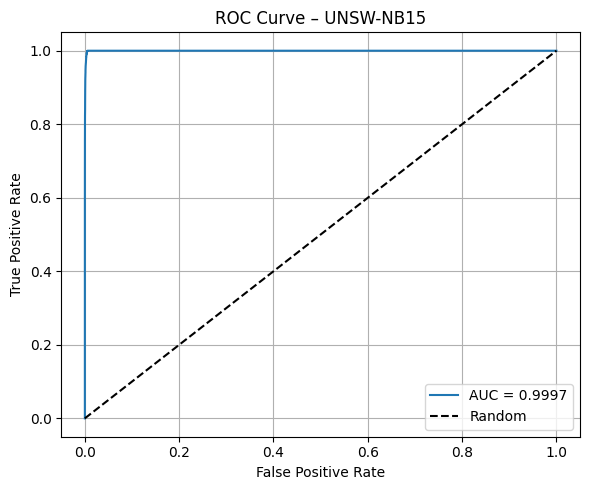

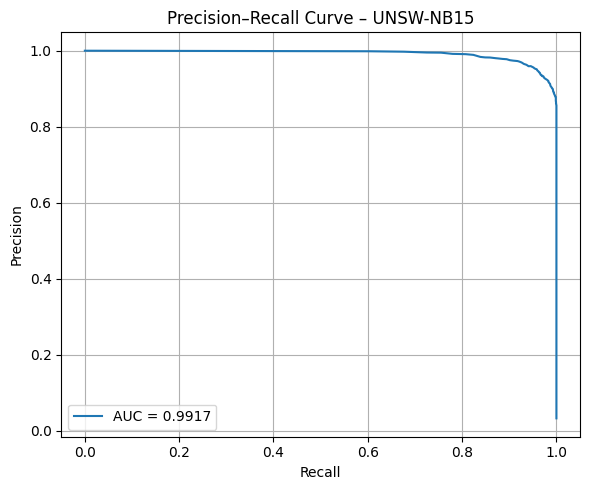

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, roc_curve, auc,
                             precision_recall_curve)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def run_rf_kfold_with_plots(X_path, y_path, prefix, n_splits=5, sample_frac=0.1):
    # Caricamento
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Reset degli indici per evitare errori successivi
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    # Campionamento del dataset (modifica la frazione a seconda delle necessità)
    sampled_indices = X.sample(frac=sample_frac, random_state=42).index
    X_sampled = X.loc[sampled_indices]  # Usando .loc per mantenere l'allineamento
    y_sampled = y.loc[sampled_indices]  # Usando .loc per mantenere l'allineamento

    # Colonne categoriche da trasformare (per esempio IP e altre variabili stringa)
    cat_cols = X_sampled.select_dtypes(include='object').columns

    # Codifica variabili categoriche
    le = LabelEncoder()
    for col in cat_cols:
        X_sampled[col] = le.fit_transform(X_sampled[col].astype(str))  # Codifica ogni colonna categorica

    # Creazione del k-fold stratificato (5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Liste per raccogliere le metriche
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Callback per Early Stopping, Riduzione del Learning Rate e Salvataggio del modello
    for train_idx, test_idx in skf.split(X_sampled, y_sampled):
        X_train, X_test = X_sampled.iloc[train_idx], X_sampled.iloc[test_idx]
        y_train, y_test = y_sampled.iloc[train_idx], y_sampled.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold saltato per una sola classe.")
            continue

        # Applicare SMOTE per bilanciare le classi nel training set
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

        # Creazione del modello Random Forest
        pipe = Pipeline([
            ("rf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
        ])

        # Addestramento e predizione
        pipe.fit(X_train_smote, y_train_smote)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        # Salvataggio delle predizioni e probabilità per calcolare le metriche
        all_y_true.extend(y_test)
        all_y_scores.extend(y_prob)

        # Calcolo delle metriche
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(rec_curve, prec_curve)
        pr_aucs.append(pr_auc)

        print(f"✅ Fold completato.")

    # Media delle metriche ottenute
    print(f"\n📊 {prefix} — Random Forest (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Lancia così:
run_rf_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')

Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  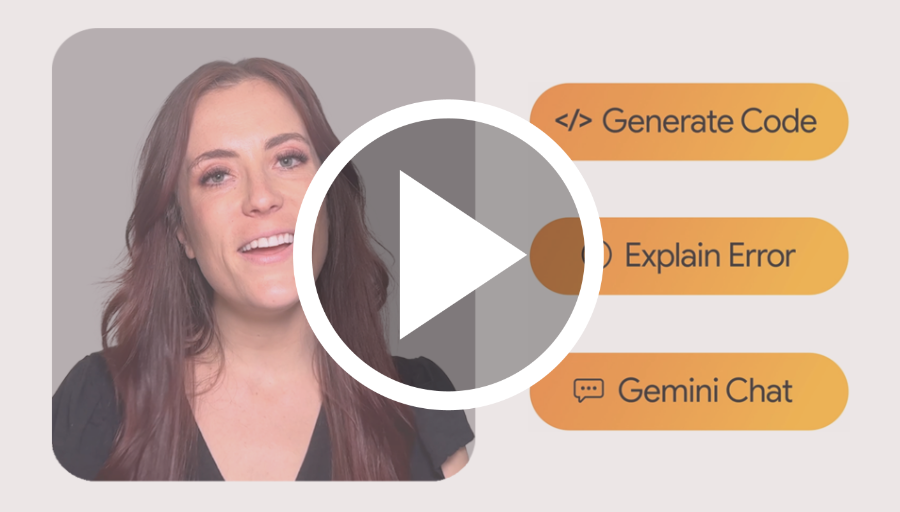
  </a>
</center>

In [4]:
import pandas as pd
import os

DATA_DIR = '/content/drive/MyDrive/CSE-CIC-IDS2018/'  # oppure il path corretto su Colab

# ✅ I file con i nomi aggiornati
files_to_use = [
    "BruteForce-Web.csv",
    "BruteForce-XSS.csv",
    "SQL-Injection.csv"
]

# ✅ Le etichette corrispondenti che vogliamo filtrare
web_labels = ["Brute Force -Web", "Brute Force -XSS", "SQL Injection"]

X_benign_list, y_benign_list = [], []
X_attack_list, y_attack_list = [], []

for filename in files_to_use:
    path = os.path.join(DATA_DIR, filename)
    print(f"📄 Carico: {filename}")
    df = pd.read_csv(path, low_memory=False)

    if 'Label' not in df.columns:
        print(f"⚠️ 'Label' mancante in {filename}")
        continue

    df_num = df.select_dtypes(include='number')
    if df_num.empty:
        print(f"⚠️ Nessuna colonna numerica in {filename}")
        continue

    labels = df['Label']

    # 🔴 Attacchi
    attack_mask = labels.isin(web_labels)
    if attack_mask.sum() > 0:
        X_attack_list.append(df_num[attack_mask])
        y_attack_list.append(pd.Series([1] * attack_mask.sum()))

    # 🟢 Benigni
    benign_mask = labels == "Benign"
    if benign_mask.sum() > 0:
        X_benign_list.append(df_num[benign_mask])
        y_benign_list.append(pd.Series([0] * benign_mask.sum()))

# 🔗 Unione
X_benign = pd.concat(X_benign_list, ignore_index=True)
y_benign = pd.concat(y_benign_list, ignore_index=True)
X_attack = pd.concat(X_attack_list, ignore_index=True)
y_attack = pd.concat(y_attack_list, ignore_index=True)

# ⚖️ Bilanciamento
min_samples = min(len(X_benign), len(X_attack))
print(f"⚖️ Bilanciamento a {min_samples} per classe")

X_benign = X_benign.sample(n=min_samples, random_state=42)
y_benign = y_benign.sample(n=min_samples, random_state=42)
X_attack = X_attack.sample(n=min_samples, random_state=42)
y_attack = y_attack.sample(n=min_samples, random_state=42)

# 🔀 Shuffle
X_bal = pd.concat([X_benign, X_attack]).sample(frac=1, random_state=42).reset_index(drop=True)
y_bal = pd.concat([y_benign, y_attack]).sample(frac=1, random_state=42).reset_index(drop=True)

# 💾 Salva
X_bal.to_csv('/content/IDS_X_web.csv', index=False)
y_bal.to_csv('/content/IDS_y_web.csv', index=False)
print("✅ Dataset filtrato e bilanciato per Web Attacks salvato.")




📄 Carico: BruteForce-Web.csv
📄 Carico: BruteForce-XSS.csv
📄 Carico: SQL-Injection.csv
⚖️ Bilanciamento a 928 per classe
✅ Dataset filtrato e bilanciato per Web Attacks salvato.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score
)
import pandas as pd
import numpy as np

def run_rf_kfold_balanced_IDS(X_path, y_path, prefix, n_splits=5):
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} ha una sola classe. Saltato.")
            fold += 1
            continue

        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completato.")
        fold += 1

    print(f"\n📊 {prefix} — Random Forest (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

# 👉 Lancia così:
run_rf_kfold_balanced_IDS('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


✅ Fold 1 completato.
✅ Fold 2 completato.
✅ Fold 3 completato.
✅ Fold 4 completato.
✅ Fold 5 completato.

📊 CSE-CIC-IDS2018-WEB — Random Forest (Stratified 5-Fold CV)
Accuracy:  0.9919 ± 0.0034
Precision: 0.9904 ± 0.0061
Recall:    0.9935 ± 0.0040
F1 Score:  0.9919 ± 0.0034
MCC:       0.9839 ± 0.0068
AUC-ROC:   0.9971
AUC-PR:    0.9943


<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_rf_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} ha una sola classe. Saltato.")
            fold += 1
            continue

        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completato.")
        fold += 1

    print(f"\n📊 {prefix} — Random Forest (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Lancia così:
run_rf_kfold_balanced_IDS('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')

✅ Fold 1 completato.
✅ Fold 2 completato.
✅ Fold 3 completato.
✅ Fold 4 completato.
✅ Fold 5 completato.

📊 CSE-CIC-IDS2018-WEB — Random Forest (Stratified 5-Fold CV)
Accuracy:  0.9919 ± 0.0034
Precision: 0.9904 ± 0.0061
Recall:    0.9935 ± 0.0040
F1 Score:  0.9919 ± 0.0034
MCC:       0.9839 ± 0.0068
AUC-ROC:   0.9971
AUC-PR:    0.9943


XGBOOST - DATASETS


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:52:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Fold completato.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:53:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Fold completato.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:53:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Fold completato.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:53:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Fold completato.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:53:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Fold completato.

📊 UNSW-NB15 — XGBoost (Stratified 5-Fold CV)
Accuracy:  0.9968 ± 0.0005
Precision: 0.9311 ± 0.0106
Recall:    0.9739 ± 0.0049
F1 Score:  0.9520 ± 0.0069
MCC:       0.9506 ± 0.0071
AUC-ROC:   0.9998
AUC-PR:    0.9939


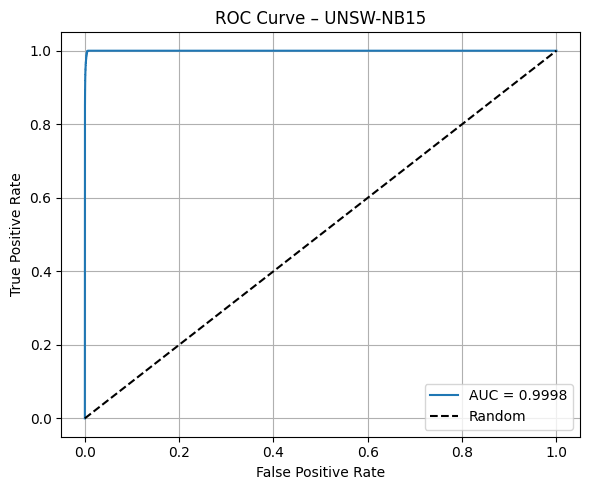

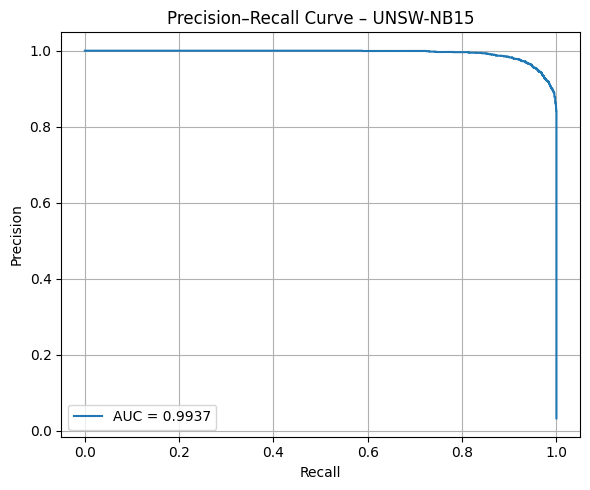

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, roc_curve, auc,
                             precision_recall_curve)
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def run_xgb_kfold_with_plots(X_path, y_path, prefix, n_splits=5, sample_frac=0.1):
    # Caricamento
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Campionamento del dataset (modifica la frazione a seconda delle necessità)
    sampled_indices = X.sample(frac=sample_frac, random_state=42).index
    X_sampled = X.loc[sampled_indices]  # Usando .loc per mantenere l'allineamento
    y_sampled = y.loc[sampled_indices]  # Usando .loc per mantenere l'allineamento

    # Colonne categoriali da trasformare
    cat_cols = X_sampled.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Esegui LabelEncoder sulle colonne categoriche
    for col in cat_cols:
        X_sampled[col] = le.fit_transform(X_sampled[col].astype(str))  # Codifica ogni colonna categorica

    # Creazione del k-fold stratificato (5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Liste per raccogliere le metriche
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Callback per Early Stopping, Riduzione del Learning Rate e Salvataggio del modello
    for train_idx, test_idx in skf.split(X_sampled, y_sampled):
        X_train, X_test = X_sampled.iloc[train_idx], X_sampled.iloc[test_idx]
        y_train, y_test = y_sampled.iloc[train_idx], y_sampled.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold saltato per una sola classe.")
            continue

        # Applicare SMOTE per bilanciare le classi nel training set
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

        # Creazione del modello XGBoost
        model = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')

        # Addestramento del modello
        model.fit(X_train_smote, y_train_smote)

        # Predizioni
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # Salvataggio delle predizioni e probabilità per calcolare le metriche
        all_y_true.extend(y_test)
        all_y_scores.extend(y_prob)

        # Calcolo delle metriche
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(rec_curve, prec_curve)
        pr_aucs.append(pr_auc)

        print(f"✅ Fold completato.")

    # Media delle metriche ottenute
    print(f"\n📊 {prefix} — XGBoost (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Lancia così:
run_xgb_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:05:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Fold 1 completato.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:05:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Fold 2 completato.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:05:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Fold 3 completato.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:05:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Fold 4 completato.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:05:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Fold 5 completato.

📊 CSE-CIC-IDS2018-WEB — XGBoost (Stratified 5-Fold CV)
Accuracy:  0.9919 ± 0.0024
Precision: 0.9893 ± 0.0047
Recall:    0.9946 ± 0.0034
F1 Score:  0.9919 ± 0.0024
MCC:       0.9839 ± 0.0048
AUC-ROC:   0.9988
AUC-PR:    0.9985


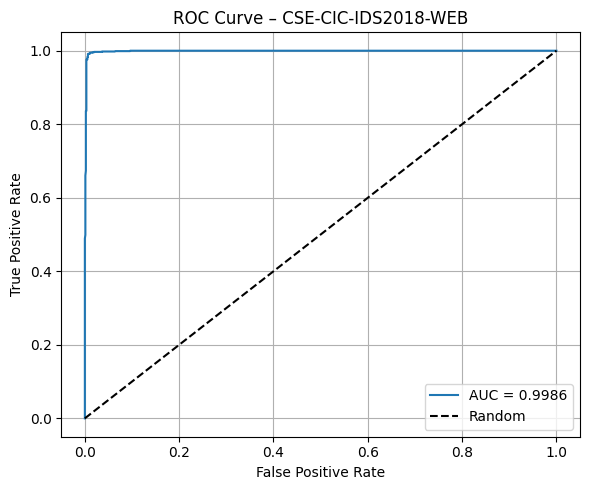

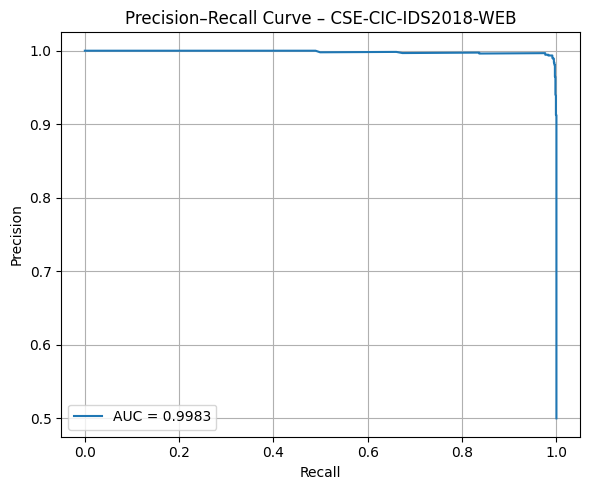

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_xgb_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} ha una sola classe. Saltato.")
            fold += 1
            continue

        # Modello XGBoost
        model = XGBClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            use_label_encoder=False,
            eval_metric='logloss',
            max_depth=6,
            min_child_weight=5,
            learning_rate=0.1
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completato.")
        fold += 1

    print(f"\n📊 {prefix} — XGBoost (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Lancia così:
run_xgb_kfold_with_plots('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


LIghtGBM


Scale Pos Weight: 30.51028584289894
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Info] Number of positive: 17772, number of negative: 542228
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6530
[LightGBM] [Info] Number of data points in the train set: 560000, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: p

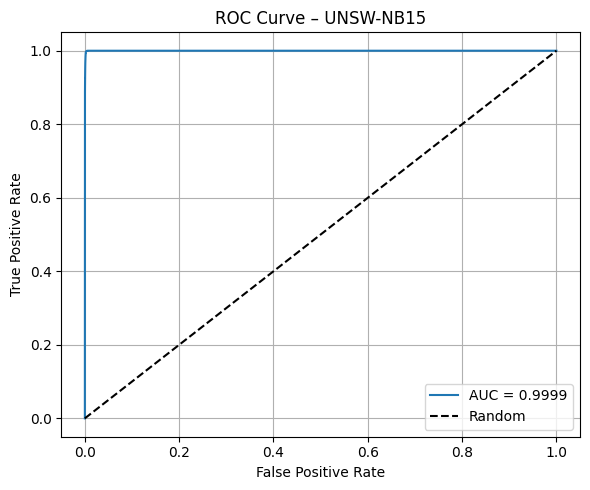

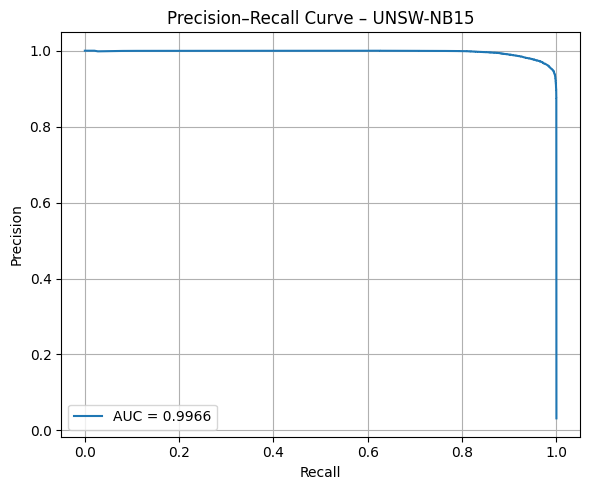

In [9]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_lgbm_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Caricamento del dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Colonne categoriche da trasformare
    categorical_cols = X.select_dtypes(include='object').columns

    # Inizializza LabelEncoder
    le = LabelEncoder()

    # Esegui il LabelEncoder sulle colonne categoriali
    for col in categorical_cols:
        # Esegui fit solo sul training set e usa il fit sul test set
        le.fit(X[col])
        X[col] = le.transform(X[col])

    # Creazione del k-fold stratificato (5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Liste per raccogliere le metriche
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Bilanciamento delle classi (in caso di dataset sbilanciato)
    scale_pos_weight = sum(y == 0) / sum(y == 1)  # Calcola il peso delle classi
    print(f"Scale Pos Weight: {scale_pos_weight}")

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} ha una sola classe. Saltato.")
            fold += 1
            continue

        # Modello LightGBM con regolarizzazione e gestione dell'overfitting
        model = lgb.LGBMClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            max_depth=6,
            min_child_samples=20,
            learning_rate=0.1,
            objective='binary',
            metric='binary_error',
            scale_pos_weight=scale_pos_weight,  # Aggiungi il peso per le classi sbilanciate
            lambda_l1=0.1,  # L1 regularization
            lambda_l2=0.1,  # L2 regularization
            min_split_gain=0.1  # Minimum gain to make a further split
        )

        model.fit(X_train, y_train)

        # Predizioni e probabilità
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Salvataggio delle predizioni e probabilità per calcolare le metriche
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Calcolo delle metriche
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completato.")
        fold += 1

    # Media delle metriche ottenute
    print(f"\n📊 {prefix} — LightGBM (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Lancia così:
run_lgbm_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')


Scale Pos Weight: 1.0
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Info] Number of positive: 742, number of negative: 742
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8631
[LightGBM] [Info] Number of data points in the train set: 1484, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positi

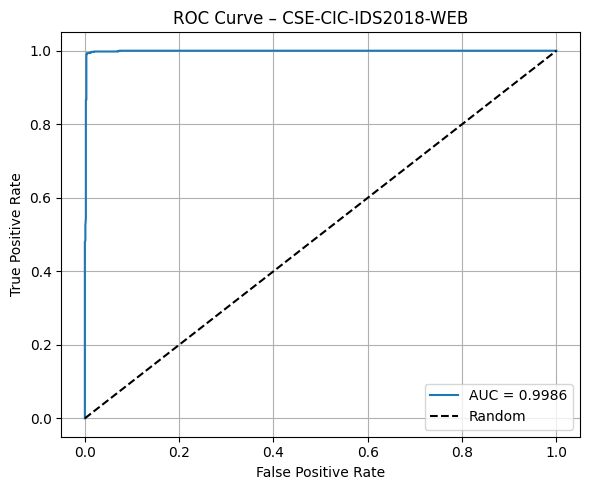

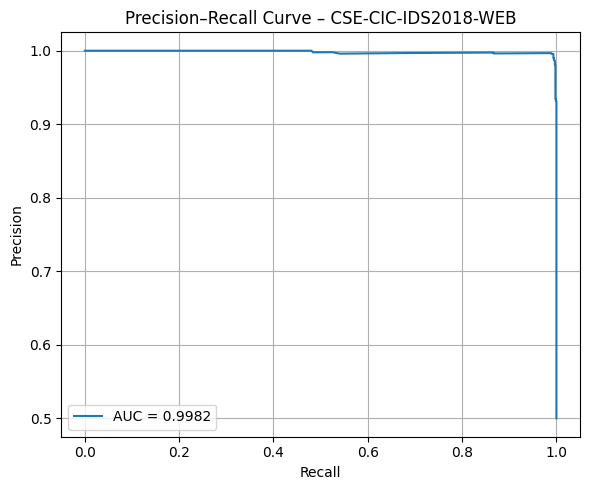

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_lgbm_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Caricamento del dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Colonne categoriche da trasformare
    categorical_cols = X.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Esegui LabelEncoder sulle colonne categoriali
    for col in categorical_cols:
        le.fit(X[col])
        X[col] = le.transform(X[col])

    # Creazione del k-fold stratificato (5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Liste per raccogliere le metriche
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Bilanciamento delle classi (in caso di dataset sbilanciato)
    scale_pos_weight = sum(y == 0) / sum(y == 1)  # Calcola il peso delle classi
    print(f"Scale Pos Weight: {scale_pos_weight}")

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} ha una sola classe. Saltato.")
            fold += 1
            continue

        # Modello LightGBM con regolarizzazione e gestione dell'overfitting
        model = lgb.LGBMClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            max_depth=6,
            min_child_samples=20,
            learning_rate=0.1,
            objective='binary',
            metric='binary_error',
            scale_pos_weight=scale_pos_weight,  # Aggiungi il peso per le classi sbilanciate
            lambda_l1=0.1,  # L1 regularization
            lambda_l2=0.1,  # L2 regularization
            min_split_gain=0.1  # Minimum gain to make a further split
        )

        model.fit(X_train, y_train)

        # Predizioni e probabilità
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Salvataggio delle predizioni e probabilità per calcolare le metriche
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Calcolo delle metriche
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completato.")
        fold += 1

    # Media delle metriche ottenute
    print(f"\n📊 {prefix} — LightGBM (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Lancia così:
run_lgbm_kfold_with_plots('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


CATBOOST


Scale Pos Weight: 30.51028584289894
0:	learn: 0.4117744	total: 667ms	remaining: 5m 32s
100:	learn: 0.0079708	total: 2m 17s	remaining: 9m 4s
200:	learn: 0.0072149	total: 4m 10s	remaining: 6m 12s
300:	learn: 0.0072146	total: 5m 15s	remaining: 3m 28s
400:	learn: 0.0072140	total: 6m 26s	remaining: 1m 35s
499:	learn: 0.0072135	total: 7m 31s	remaining: 0us
✅ Fold 1 completato.
0:	learn: 0.3790821	total: 1.35s	remaining: 11m 14s
100:	learn: 0.0080389	total: 2m 20s	remaining: 9m 16s
200:	learn: 0.0075095	total: 4m 23s	remaining: 6m 31s
300:	learn: 0.0075091	total: 5m 29s	remaining: 3m 38s
400:	learn: 0.0075087	total: 6m 49s	remaining: 1m 41s
499:	learn: 0.0075081	total: 8m 10s	remaining: 0us
✅ Fold 2 completato.
0:	learn: 0.3796820	total: 1.3s	remaining: 10m 51s
100:	learn: 0.0081840	total: 2m 26s	remaining: 9m 38s
200:	learn: 0.0075607	total: 4m 18s	remaining: 6m 24s
300:	learn: 0.0073823	total: 5m 42s	remaining: 3m 46s
400:	learn: 0.0073764	total: 7m 4s	remaining: 1m 44s
499:	learn: 0.007344

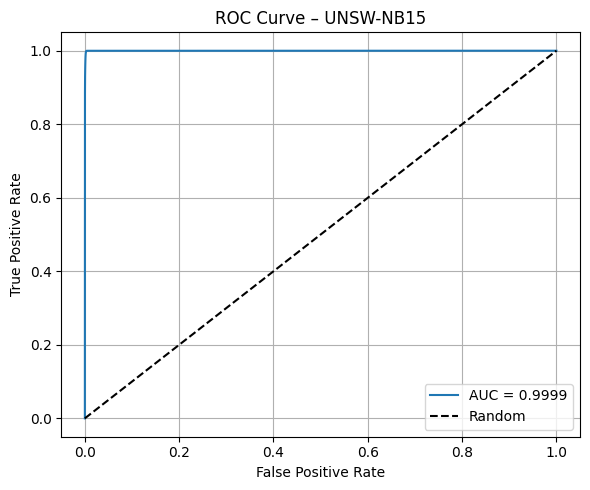

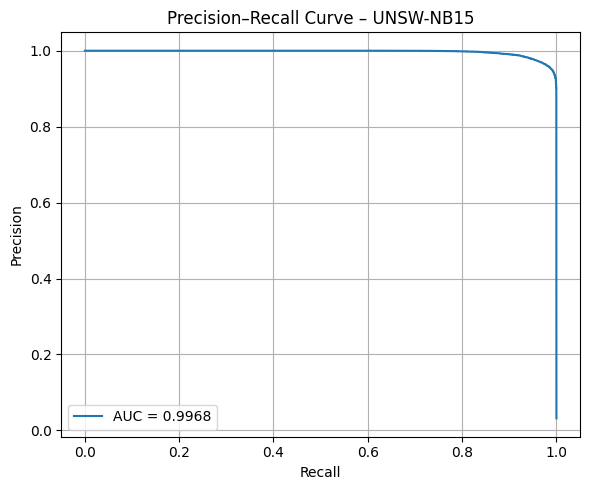

In [ ]:
import catboost as cb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_catboost_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Caricamento del dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Colonne categoriali da trasformare
    categorical_cols = X.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Esegui LabelEncoder sulle colonne categoriali
    for col in categorical_cols:
        le.fit(X[col])
        X[col] = le.transform(X[col])

    # Creazione del k-fold stratificato (5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Liste per raccogliere le metriche
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Bilanciamento delle classi (in caso di dataset sbilanciato)
    scale_pos_weight = sum(y == 0) / sum(y == 1)  # Calcola il peso delle classi
    print(f"Scale Pos Weight: {scale_pos_weight}")

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} ha una sola classe. Saltato.")
            fold += 1
            continue

        # Modello CatBoost con regolarizzazione e gestione dell'overfitting
        model = cb.CatBoostClassifier(
            iterations=500,  # Riduci il numero di iterazioni per velocizzare
            depth=6,  # Riduci la profondità dell'albero
            num_leaves=31,  # Imposta un numero basso di foglie
            learning_rate=0.1,
            cat_features=[X.columns.get_loc(col) for col in categorical_cols],  # Indica le colonne categoriche
            loss_function='Logloss',
            random_state=42,
            verbose=100,  # Mostra progressi ogni 100 iterazioni
            scale_pos_weight=scale_pos_weight,
            early_stopping_rounds=50,  # Aggiungi early stopping
            task_type='CPU',  # Disabilita l'uso della GPU
            thread_count=-1  # Usa tutte le CPU disponibili
        )

        model.fit(X_train, y_train)

        # Predizioni e probabilità
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Salvataggio delle predizioni e probabilità per calcolare le metriche
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Calcolo delle metriche
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completato.")
        fold += 1

    # Media delle metriche ottenute
    print(f"\n📊 {prefix} — CatBoost (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Lancia così:
run_catboost_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')


Scale Pos Weight: auto_class_weights='Balanced'
0:	learn: 0.5247347	total: 136ms	remaining: 1m 7s
100:	learn: 0.0062597	total: 14.5s	remaining: 57.3s
200:	learn: 0.0052361	total: 29.5s	remaining: 43.9s
300:	learn: 0.0048631	total: 43.1s	remaining: 28.5s
400:	learn: 0.0048307	total: 55s	remaining: 13.6s
499:	learn: 0.0048139	total: 1m 5s	remaining: 0us
✅ Fold completato.
0:	learn: 0.5239866	total: 119ms	remaining: 59.6s
100:	learn: 0.0060304	total: 14.1s	remaining: 55.8s
200:	learn: 0.0045560	total: 28.6s	remaining: 42.5s
300:	learn: 0.0040956	total: 42.3s	remaining: 28s
400:	learn: 0.0038582	total: 54.4s	remaining: 13.4s
499:	learn: 0.0036843	total: 1m 6s	remaining: 0us
✅ Fold completato.
0:	learn: 0.5232570	total: 120ms	remaining: 1m
100:	learn: 0.0060354	total: 14.4s	remaining: 56.7s
200:	learn: 0.0047941	total: 29.7s	remaining: 44.2s
300:	learn: 0.0044139	total: 42.6s	remaining: 28.1s
400:	learn: 0.0043850	total: 52.5s	remaining: 13s
499:	learn: 0.0043845	total: 1m 1s	remaining: 0us

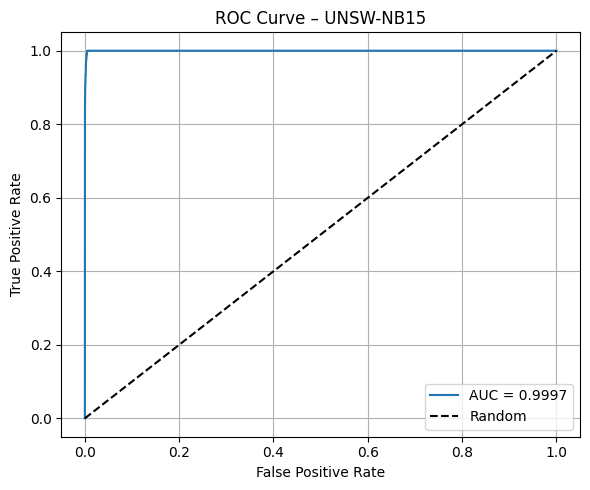

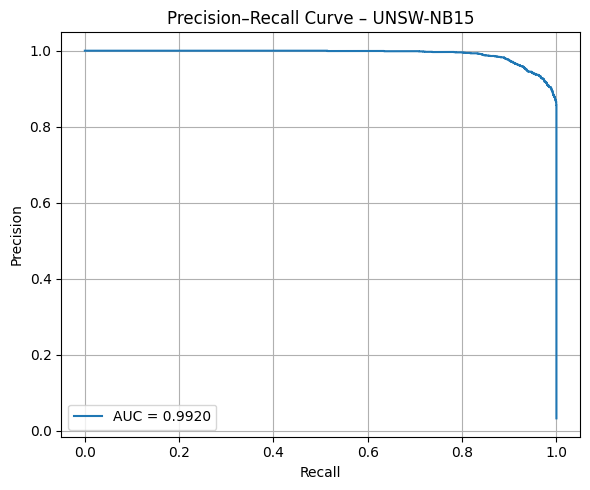

In [18]:
import catboost as cb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve, auc)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE

def run_catboost_kfold_with_plots(X_path, y_path, prefix, n_splits=5, sample_frac=0.1):
    # Caricamento del dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Campionamento del dataset (modifica la frazione a seconda delle necessità)
    sampled_indices = X.sample(frac=sample_frac, random_state=42).index
    X_sampled = X.loc[sampled_indices]  # Usando .loc per mantenere l'allineamento
    y_sampled = y.loc[sampled_indices]  # Usando .loc per mantenere l'allineamento

    # Colonne categoriali da trasformare
    cat_cols = X_sampled.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Esegui LabelEncoder sulle colonne categoriche
    for col in cat_cols:
        X_sampled[col] = le.fit_transform(X_sampled[col].astype(str))  # Codifica ogni colonna categorica

    # Creazione del k-fold stratificato (5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Liste per raccogliere le metriche
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Bilanciamento delle classi (in caso di dataset sbilanciato)
    # Usa auto_class_weights per il bilanciamento automatico delle classi
    print(f"Scale Pos Weight: auto_class_weights='Balanced'")

    fold = 1
    for train_idx, test_idx in skf.split(X_sampled, y_sampled):
        X_train, X_test = X_sampled.iloc[train_idx], X_sampled.iloc[test_idx]
        y_train, y_test = y_sampled.iloc[train_idx], y_sampled.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold saltato per una sola classe.")
            continue

        # Applicare SMOTE per bilanciare le classi nel training set
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

        # Modello CatBoost con regolarizzazione e gestione dell'overfitting
        model = cb.CatBoostClassifier(
            iterations=500,  # Riduci il numero di iterazioni per velocizzare
            depth=5,  # Riduci la profondità dell'albero
            num_leaves=31,  # Imposta un numero basso di foglie
            learning_rate=0.05,  # Riduci il learning rate per un miglior controllo
            cat_features=[X_sampled.columns.get_loc(col) for col in cat_cols],  # Indica le colonne categoriche
            loss_function='Logloss',
            random_state=42,
            verbose=100,  # Mostra progressi ogni 100 iterazioni
            auto_class_weights='Balanced',  # Bilanciamento automatico delle classi
            early_stopping_rounds=50,  # Aggiungi early stopping
            task_type='CPU',  # Disabilita l'uso della GPU
            thread_count=-1,  # Usa tutte le CPU disponibili
            l2_leaf_reg=3.0,  # Aggiungi maggiore regolarizzazione L2 per prevenire l'overfitting
        )

        model.fit(X_train_smote, y_train_smote)

        # Predizioni e probabilità
        threshold = 0.3  # Impostazione della soglia di classificazione
        y_pred = (model.predict_proba(X_test)[:, 1] > threshold).astype("int32")
        y_score = model.predict_proba(X_test)[:, 1]

        # Salvataggio delle predizioni e probabilità per calcolare le metriche
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Calcolo delle metriche
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold completato.")
        fold += 1

    # Media delle metriche ottenute
    print(f"\n📊 {prefix} — CatBoost (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Lancia così:
run_catboost_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')

Scale Pos Weight: 1.0
0:	learn: 0.5159322	total: 16.2ms	remaining: 8.08s
100:	learn: 0.0075682	total: 2.61s	remaining: 10.3s
200:	learn: 0.0036573	total: 4.87s	remaining: 7.25s
300:	learn: 0.0033177	total: 6.1s	remaining: 4.03s
400:	learn: 0.0032199	total: 7.32s	remaining: 1.81s
499:	learn: 0.0031608	total: 8.54s	remaining: 0us
✅ Fold 1 completato.
0:	learn: 0.5337399	total: 17.1ms	remaining: 8.53s
100:	learn: 0.0123264	total: 1.26s	remaining: 4.99s
200:	learn: 0.0083930	total: 2.47s	remaining: 3.68s
300:	learn: 0.0080874	total: 3.69s	remaining: 2.44s
400:	learn: 0.0080843	total: 4.89s	remaining: 1.21s
499:	learn: 0.0074115	total: 6.45s	remaining: 0us
✅ Fold 2 completato.
0:	learn: 0.4897566	total: 32.7ms	remaining: 16.3s
100:	learn: 0.0099423	total: 2.78s	remaining: 11s
200:	learn: 0.0040830	total: 4.45s	remaining: 6.62s
300:	learn: 0.0032642	total: 5.65s	remaining: 3.74s
400:	learn: 0.0032247	total: 6.92s	remaining: 1.71s
499:	learn: 0.0032241	total: 8.11s	remaining: 0us
✅ Fold 3 com

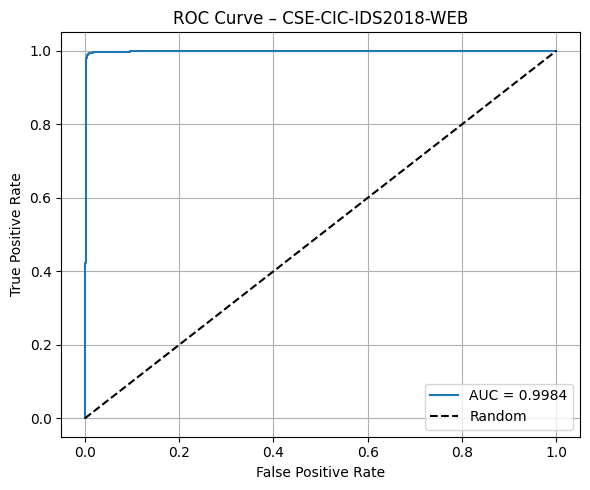

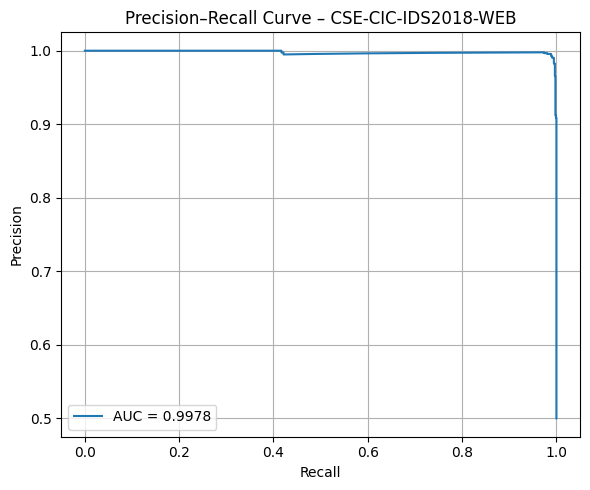

In [ ]:
import catboost as cb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_catboost_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Caricamento del dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Colonne categoriali da trasformare
    categorical_cols = X.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Esegui LabelEncoder sulle colonne categoriali
    for col in categorical_cols:
        le.fit(X[col])
        X[col] = le.transform(X[col])

    # Creazione del k-fold stratificato (5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Liste per raccogliere le metriche
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Bilanciamento delle classi (in caso di dataset sbilanciato)
    scale_pos_weight = sum(y == 0) / sum(y == 1)  # Calcola il peso delle classi
    print(f"Scale Pos Weight: {scale_pos_weight}")

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} ha una sola classe. Saltato.")
            fold += 1
            continue

        # Modello CatBoost con regolarizzazione e gestione dell'overfitting
        model = cb.CatBoostClassifier(
            iterations=500,  # Riduci il numero di iterazioni per velocizzare
            depth=6,  # Riduci la profondità dell'albero
            num_leaves=31,  # Imposta un numero basso di foglie
            learning_rate=0.1,
            cat_features=[X.columns.get_loc(col) for col in categorical_cols],  # Indica le colonne categoriche
            loss_function='Logloss',
            random_state=42,
            verbose=100,  # Mostra progressi ogni 100 iterazioni
            scale_pos_weight=scale_pos_weight,
            early_stopping_rounds=50,  # Aggiungi early stopping
            task_type='CPU',  # Disabilita l'uso della GPU
            thread_count=-1  # Usa tutte le CPU disponibili
        )

        model.fit(X_train, y_train)

        # Predizioni e probabilità
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Salvataggio delle predizioni e probabilità per calcolare le metriche
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Calcolo delle metriche
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completato.")
        fold += 1

    # Media delle metriche ottenute
    print(f"\n📊 {prefix} — CatBoost (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Lancia così:
run_catboost_kfold_with_plots('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


DNN

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
✅ Fold 1 completato.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
✅ Fold 2 completato.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
✅ Fold 3 completato.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
✅ Fold 4 completato.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
✅ Fold 5 completato.

📊 CSE-CIC-IDS2018-WEB — DNN (Stratified 5-Fold CV)
Accuracy:  0.8373 ± 0.0638
Precision: 0.9506 ± 0.0129
Recall:    0.7099 ± 0.1255
F1 Score:  0.8075 ± 0.0844
MCC:       0.7001 ± 0.1111
AUC-ROC:   0.9678
AUC-PR:    0.9614


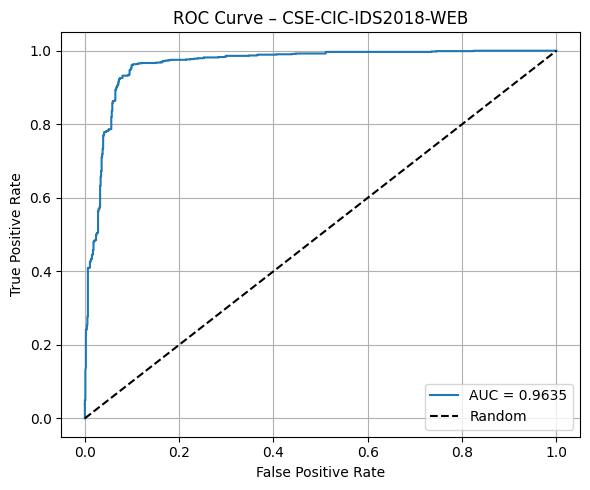

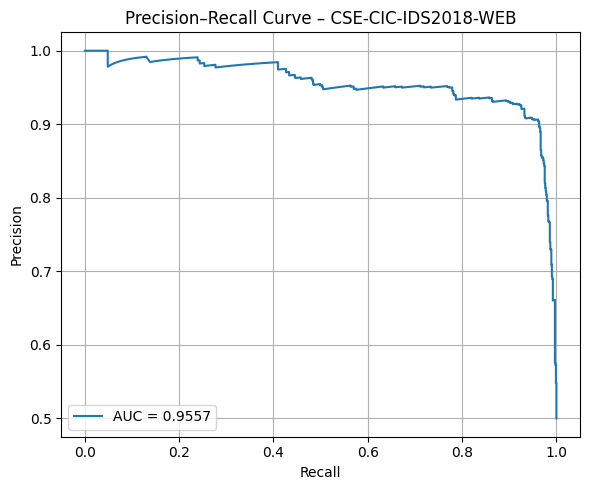

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_dnn_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Caricamento del dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Colonne categoriali da trasformare
    categorical_cols = X.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Esegui LabelEncoder sulle colonne categoriali
    for col in categorical_cols:
        le.fit(X[col])
        X[col] = le.transform(X[col])

    # Creazione del k-fold stratificato (5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Liste per raccogliere le metriche
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Callback per Early Stopping e Riduzione del Learning Rate
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=10, restore_best_weights=True)

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} ha una sola classe. Saltato.")
            fold += 1
            continue

        # Creazione del modello DNN (Deep Neural Network)
        model = Sequential()
        model.add(Dense(256, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.01)))  # Primo hidden layer
        model.add(BatchNormalization())  # Normalizzazione
        model.add(Dropout(0.5))  # Regularizzazione tramite dropout
        model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))  # Secondo hidden layer
        model.add(BatchNormalization())  # Normalizzazione
        model.add(Dropout(0.5))  # Regularizzazione tramite dropout
        model.add(Dense(64, activation='relu'))  # Terzo hidden layer
        model.add(Dense(1, activation='sigmoid'))  # Output layer (binary classification)

        # Compilazione del modello
        model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

        # Addestramento del modello con early stopping e reduce learning rate
        model.fit(X_train, y_train, epochs=100, batch_size=64, verbose=0, validation_data=(X_test, y_test),
                  callbacks=[early_stopping, reduce_lr])

        # Predizioni
        y_pred = (model.predict(X_test) > 0.5).astype("int32")
        y_score = model.predict(X_test)

        # Salvataggio delle predizioni e probabilità per calcolare le metriche
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Calcolo delle metriche
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completato.")
        fold += 1

    # Media delle metriche ottenute
    print(f"\n📊 {prefix} — DNN (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Lancia così:
run_dnn_kfold_with_plots('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
✅ Fold 1 completato.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
✅ Fold 2 completato.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
✅ Fold 3 completato.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
✅ Fold 4 completato.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
✅ Fold 5 completato.

📊 UNSW-NB15 — DNN (Stratified 5-Fold CV)
Accuracy:  0.9749 ± 0.0013
Precision: 0.6903 ± 0.0405
Recall:    0.4311 ± 0.0181
F1 Score:  0.5301 ± 0.0188
MCC:       0.5334 ± 0.0207
AUC-ROC:   0.9281
AUC-PR:    0.6057


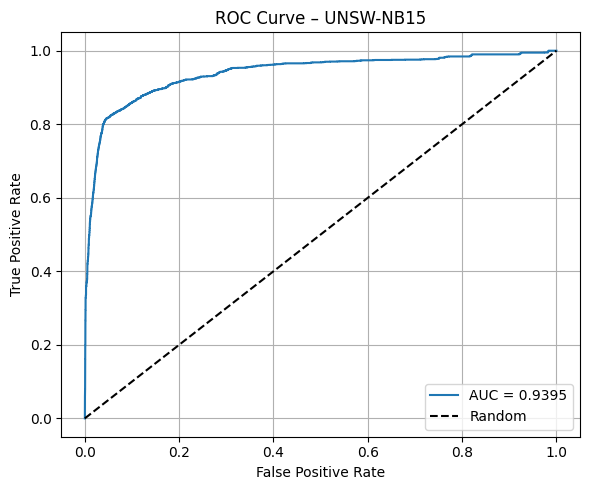

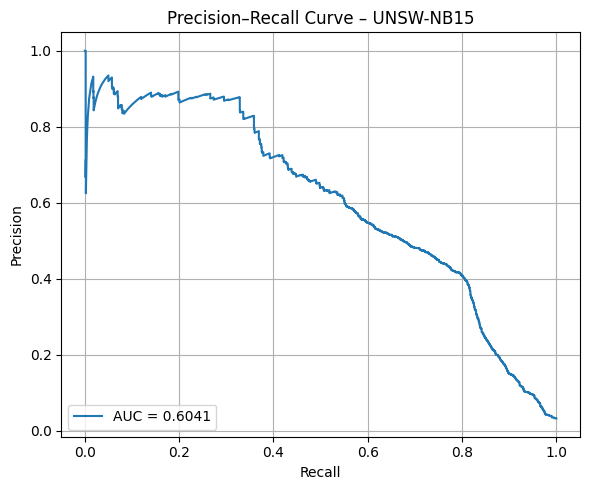

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_dnn_kfold_with_plots(X_path, y_path, prefix, n_splits=5, sample_frac=0.1):
    # Caricamento del dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Reset degli indici per evitare errori successivi
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    # Campionamento del dataset (modifica la frazione a seconda delle necessità)
    sampled_indices = X.sample(frac=sample_frac, random_state=42).index
    X_sampled = X.loc[sampled_indices]  # Usando .loc per mantenere l'allineamento
    y_sampled = y.loc[sampled_indices]  # Usando .loc per mantenere l'allineamento

    # Colonne categoriali da trasformare
    categorical_cols = X_sampled.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Esegui LabelEncoder sulle colonne categoriali
    for col in categorical_cols:
        le.fit(X_sampled[col])
        X_sampled[col] = le.transform(X_sampled[col])

    # Creazione del k-fold stratificato (5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Liste per raccogliere le metriche
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Callback per Early Stopping e Riduzione del Learning Rate
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=10, restore_best_weights=True)

    fold = 1
    for train_idx, test_idx in skf.split(X_sampled, y_sampled):
        X_train, X_test = X_sampled.iloc[train_idx], X_sampled.iloc[test_idx]
        y_train, y_test = y_sampled.iloc[train_idx], y_sampled.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} ha una sola classe. Saltato.")
            fold += 1
            continue

        # Creazione del modello DNN (Deep Neural Network)
        model = Sequential()
        model.add(Dense(256, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.01)))  # Primo hidden layer
        model.add(BatchNormalization())  # Normalizzazione
        model.add(Dropout(0.5))  # Regularizzazione tramite dropout
        model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))  # Secondo hidden layer
        model.add(BatchNormalization())  # Normalizzazione
        model.add(Dropout(0.5))  # Regularizzazione tramite dropout
        model.add(Dense(64, activation='relu'))  # Terzo hidden layer
        model.add(Dense(1, activation='sigmoid'))  # Output layer (binary classification)

        # Compilazione del modello
        model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

        # Addestramento del modello con early stopping e reduce learning rate
        model.fit(X_train, y_train, epochs=100, batch_size=64, verbose=0, validation_data=(X_test, y_test),
                  callbacks=[early_stopping, reduce_lr])

        # Predizioni
        y_pred = (model.predict(X_test) > 0.5).astype("int32")
        y_score = model.predict(X_test)

        # Salvataggio delle predizioni e probabilità per calcolare le metriche
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Calcolo delle metriche
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completato.")
        fold += 1

    # Media delle metriche ottenute
    print(f"\n📊 {prefix} — DNN (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Ora genera i grafici usando tutti i fold combinati
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PR
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Lancia così:
run_dnn_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')


LSTM


<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

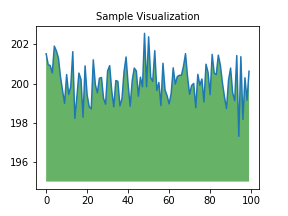

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)
- [Linear regression with tf.keras using synthetic data](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/linear_regression_with_synthetic_data.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [TensorFlow with GPUs](/notebooks/gpu.ipynb)
- [TPUs in Colab](/notebooks/tpu.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Retraining an Image Classifier](https://tensorflow.org/hub/tutorials/tf2_image_retraining): Build a Keras model on top of a pre-trained image classifier to distinguish flowers.
- [Text Classification](https://tensorflow.org/hub/tutorials/tf2_text_classification): Classify IMDB movie reviews as either *positive* or *negative*.
- [Style Transfer](https://tensorflow.org/hub/tutorials/tf2_arbitrary_image_stylization): Use deep learning to transfer style between images.
- [Multilingual Universal Sentence Encoder Q&A](https://tensorflow.org/hub/tutorials/retrieval_with_tf_hub_universal_encoder_qa): Use a machine learning model to answer questions from the SQuAD dataset.
- [Video Interpolation](https://tensorflow.org/hub/tutorials/tweening_conv3d): Predict what happened in a video between the first and the last frame.
